# Lab Optical Flow

## Installazione


In [ ]:
!python -m venv CV_lezione
!source CV_lezione/bin/activate
pip install numpy opencv-python torch matplotlib jupyterlab

In [ ]:
!source CV_lezione/bin/activate

Installazione delle dipendenze necessarie

In [ ]:
!pip install numpy opencv-python torch matplotlib jupyterlab

In [61]:
import struct
import numpy as np
import cv2
import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision.models.optical_flow import raft_large, Raft_Large_Weights

Eseguire la cella successiva per scaricare il dataset

In [51]:
!wget http://files.is.tue.mpg.de/sintel/MPI-Sintel-complete.zip
!unzip MPI-Sintel-complete.zip -d MPI-Sintel

--2026-03-12 10:11:56--  http://files.is.tue.mpg.de/sintel/MPI-Sintel-complete.zip
Resolving files.is.tue.mpg.de (files.is.tue.mpg.de)... 192.124.27.139
Connecting to files.is.tue.mpg.de (files.is.tue.mpg.de)|192.124.27.139|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.is.tue.mpg.de/sintel/MPI-Sintel-complete.zip [following]
--2026-03-12 10:11:57--  https://files.is.tue.mpg.de/sintel/MPI-Sintel-complete.zip
Connecting to files.is.tue.mpg.de (files.is.tue.mpg.de)|192.124.27.139|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5627783629 (5.2G) [application/zip]
Saving to: ‘MPI-Sintel-complete.zip.1’

       MPI-Sintel-c   0%[                    ]  16.89M  --.-KB/s    eta 2h 39m ^C
Archive:  MPI-Sintel-complete.zip
replace MPI-Sintel/bundler/win/bundler.exe? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


Iperparametri

In [62]:
SINTEL_ROOT = Path("MPI-Sintel/training")
SCENE       = "alley_1"       # cambia con qualsiasi scena del dataset
FRAME_IDX   = 1               # carica frame_000X.png e frame_000(X+1).png

## Dataset

Le seguenti due funzioni leggono il dataset MPI-Sintel e i suoi fie contenenti gli optical flow corretti che verranno utilizzati come ground truth

In [63]:
def read_flo(path):
    """Legge un file .flo del formato MPI-Sintel → numpy array (H, W, 2)."""
    with open(path, "rb") as f:
        magic = struct.unpack("f", f.read(4))[0]
        assert magic == 202021.25, "File .flo non valido (magic number errato)"
        w = struct.unpack("i", f.read(4))[0]
        h = struct.unpack("i", f.read(4))[0]
        data = np.frombuffer(f.read(), dtype=np.float32)
    return data.reshape(h, w, 2)   # [..., 0]=dx, [..., 1]=dy

In [64]:
def load_frames_and_gt(sintel_root, scene, idx):
    """
    Carica due frame consecutivi e il ground truth optical flow.
    Sintel usa file .flo con un formato binario custom (Magic: PIEH).
    """
    clean_dir = sintel_root / "clean" / scene
    flow_dir  = sintel_root / "flow"  / scene

    frame1_path = clean_dir / f"frame_{idx:04d}.png"
    frame2_path = clean_dir / f"frame_{idx+1:04d}.png"
    flow_path   = flow_dir  / f"frame_{idx:04d}.flo"

    frame1 = cv2.cvtColor(cv2.imread(str(frame1_path)), cv2.COLOR_BGR2RGB)
    frame2 = cv2.cvtColor(cv2.imread(str(frame2_path)), cv2.COLOR_BGR2RGB)
    flow_gt = read_flo(flow_path)

    return frame1, frame2, flow_gt

## Optical Flow classsico: Algoritmo di Farneback
L'algoritmo guarda ogni frame e cerca di descrivere l'intensità dei pixel in un piccolo vicinato utilizzando una funzione quadratica (un paraboloide). In pratica, modella la superficie luminosa dell'immagine locale.

In [65]:
def classical_flow(frame1_rgb, frame2_rgb):
    """Dense optical flow con l'algoritmo di Farneback (OpenCV)."""
    gray1 = cv2.cvtColor(frame1_rgb, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(frame2_rgb, cv2.COLOR_RGB2GRAY)
    flow = cv2.calcOpticalFlowFarneback(
        gray1, gray2, None,
        pyr_scale=0.5, levels=5, winsize=15,
        iterations=3, poly_n=5, poly_sigma=1.2,
        flags=0
    )
    return flow   # (H, W, 2)

## Optical Flow deep learning: RAFT
RAFT (Recurrent All-Pairs Field Transforms) è un modello di deep learning presentato nel 2020. [Link al paper](https://www.ecva.net/papers/eccv_2020/papers_ECCV/papers/123470392.pdf)

In [66]:
def raft_flow(frame1_rgb, frame2_rgb):
    """
    Optical flow con RAFT (torchvision), pesi pretrained
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Pesi e trasformazioni di preprocessing ufficiali
    weights    = Raft_Large_Weights.DEFAULT
    transforms = weights.transforms()
    model      = raft_large(weights=weights, progress=True).to(device).eval()

    # numpy (H,W,3) uint8  →  tensor (1,3,H,W)
    t1 = TF.to_tensor(frame1_rgb).unsqueeze(0)
    t2 = TF.to_tensor(frame2_rgb).unsqueeze(0)

    # Le dimensioni devono essere divisibili per 8
    H, W = frame1_rgb.shape[:2]
    H8   = (H // 8) * 8
    W8   = (W // 8) * 8
    t1   = TF.resize(t1, [H8, W8], antialias=False)
    t2   = TF.resize(t2, [H8, W8], antialias=False)

    # Preprocessing ufficiale: normalizza in [-1, 1]
    t1, t2 = transforms(t1, t2)

    with torch.no_grad():
        # RAFT restituisce una lista di flussi (uno per ogni iterazione);
        # l'ultimo è il più preciso.
        flow_list = model(t1.to(device), t2.to(device))
        flow_tensor = flow_list[-1]   # (1, 2, H8, W8)

    # Riporta alle dimensioni originali e converte in numpy (H, W, 2)
    flow_tensor = TF.resize(flow_tensor, [H, W], antialias=False)
    flow_np = flow_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    return flow_np   # (H, W, 2)

## Metriche

In [67]:
def endpoint_error(flow_pred, flow_gt):
    """EPE (End-Point Error): distanza euclidea media pixel-per-pixel."""
    diff = flow_pred - flow_gt
    epe  = np.sqrt((diff[..., 0]**2 + diff[..., 1]**2))
    return epe.mean()

## Visualizzazione

In [68]:
def flow_to_rgb(flow):
    """
    Mappa il campo di flusso (H,W,2) in un'immagine RGB:
      hue      → direzione del moto
      luminosità → magnitudo (intensità del moto)
    """
    fx, fy    = flow[..., 0], flow[..., 1]
    magnitude = np.sqrt(fx**2 + fy**2)
    angle     = np.arctan2(fy, fx)                     # [-π, π]

    # hue in [0,1], saturation=1, value normalizzato
    hue = (angle + np.pi) / (2 * np.pi)
    val = magnitude / (magnitude.max() + 1e-5)

    # colore = cmap(hue) * luminosità
    rgb = plt.cm.hsv(hue)[..., :3] * val[..., np.newaxis]
    return np.clip(rgb, 0, 1)


def visualize(frame1, frame2, flow_gt, flow_classical, flow_raft,
              epe_classical, epe_raft):

    fig, axes = plt.subplots(2, 4, figsize=(18, 9))
    fig.suptitle(
        f"Optical Flow  —  Scena: {SCENE}, frame {FRAME_IDX}\n"
        f"EPE classico: {epe_classical:.2f} px  |  EPE RAFT: {epe_raft:.2f} px",
        fontsize=13
    )

    # riga superiore: immagini e flussi visualizzati come RGB
    axes[0, 0].imshow(frame1);                  axes[0, 0].set_title("Frame 1")
    axes[0, 1].imshow(frame2);                  axes[0, 1].set_title("Frame 2")
    axes[0, 2].imshow(flow_to_rgb(flow_gt));    axes[0, 2].set_title("Ground Truth (Sintel)")
    axes[0, 3].imshow(np.zeros((10, 10)))       # leggenda colori

    # leggenda HSV (ruota dei colori)
    ax_leg = axes[0, 3]
    ax_leg.set_title("Legenda colori\n(hue=direzione)")
    theta  = np.linspace(0, 2 * np.pi, 360)
    r      = np.linspace(0, 1, 50)
    T, R   = np.meshgrid(theta, r)
    legend = plt.cm.hsv(T / (2 * np.pi))[..., :3] * R[..., np.newaxis]
    ax_leg.imshow(legend, extent=[-np.pi, np.pi, 0, 1], aspect='auto', origin='lower')
    ax_leg.set_xlabel("direzione (rad)")
    ax_leg.set_ylabel("magnitudo (norm.)")

    # riga inferiore: campi vettoriali
    step = 16
    H, W = frame1.shape[:2]
    Y, X = np.mgrid[0:H:step, 0:W:step]

    pairs = [
        (axes[1, 1], flow_classical, f"Vettori classico  (EPE={epe_classical:.2f}px)"),
        (axes[1, 2], flow_gt,        "Vettori GT"),
        (axes[1, 3], flow_raft,      f"Vettori RAFT  (EPE={epe_raft:.2f}px)"),
    ]
    for ax, flow, title in pairs:
        ax.imshow(frame1, alpha=0.6)
        ax.quiver(X, Y,
                  flow[::step, ::step, 0],
                  flow[::step, ::step, 1],
                  color='red', scale=300, width=0.002)
        ax.set_title(title)

    axes[1, 0].imshow(flow_to_rgb(flow_classical))
    axes[1, 0].set_title(f"Classico (Farneback)\nEPE={epe_classical:.2f}px")

    # aggiungi anche RAFT come RGB nella riga superiore
    axes[0, 2].set_title("Ground Truth (Sintel)")
    # riuso axes[1,3] già impostato; aggiungi RAFT RGB in 0,3 sovrascrivendo la leggenda
    # (sposta leggenda in alto a destra di [0,3] e metti RAFT in [1,3])
    # nota: axes[1,3] è già il quiver di RAFT → aggiungo RAFT RGB come inset
    axins = axes[0, 3].inset_axes([0, 0, 1, 1])
    axins.imshow(flow_to_rgb(flow_raft))
    axins.set_title(f"RAFT pretrained\nEPE={epe_raft:.2f}px")
    axins.axis('off')
    axes[0, 3].axis('off')

    for ax in axes.flat:
        ax.axis('off')

    plt.tight_layout()
    out = "optical_flow_sintel_raft.png"
    plt.savefig(out, dpi=120)
    plt.show()
    print(f"Immagine salvata come '{out}'")

## Main

=== Carico i frame da MPI-Sintel  [alley_1, frame 1] ===
    Dimensioni: (436, 1024, 3)  |  GT flow range: dx=[-8.4, 1.2]  dy=[-2.7, 4.2]

=== Optical flow classico (Farneback) ===
    EPE = 0.873 px

=== Optical flow RAFT pretrained ===
    EPE = 0.111 px

=== Visualizzazione ===


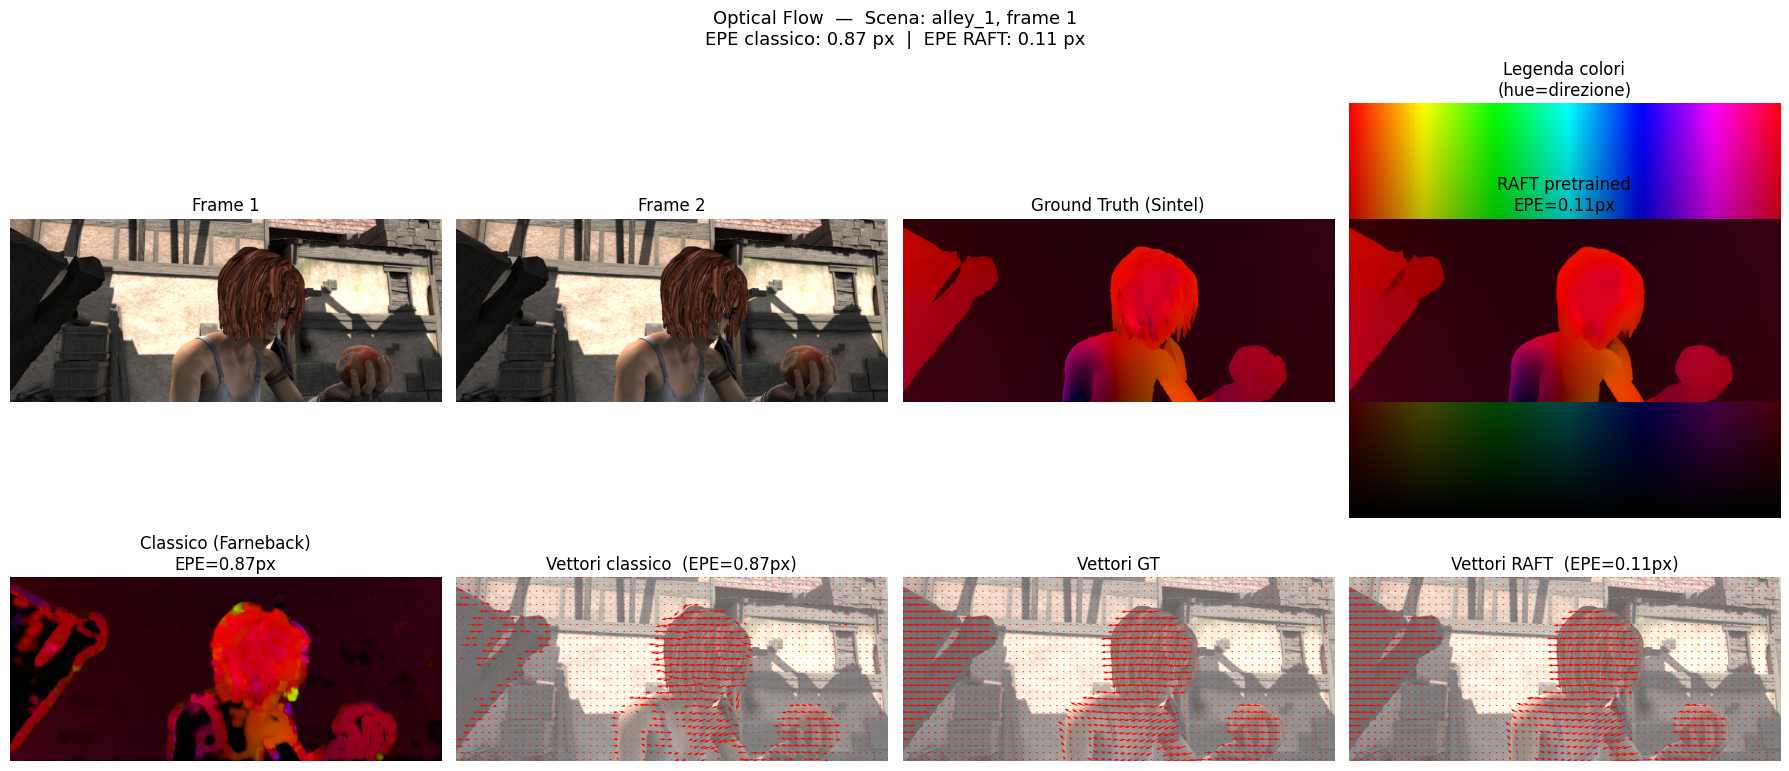

Immagine salvata come 'optical_flow_sintel_raft.png'


In [69]:
print(f"=== Carico i frame da MPI-Sintel  [{SCENE}, frame {FRAME_IDX}] ===")
frame1, frame2, flow_gt = load_frames_and_gt(SINTEL_ROOT, SCENE, FRAME_IDX)
print(f"    Dimensioni: {frame1.shape}  |  GT flow range: "
      f"dx=[{flow_gt[...,0].min():.1f}, {flow_gt[...,0].max():.1f}]  "
      f"dy=[{flow_gt[...,1].min():.1f}, {flow_gt[...,1].max():.1f}]")

print("\n=== Optical flow classico (Farneback) ===")
flow_classical = classical_flow(frame1, frame2)
epe_classical  = endpoint_error(flow_classical, flow_gt)
print(f"    EPE = {epe_classical:.3f} px")

print("\n=== Optical flow RAFT pretrained ===")
flow_raft = raft_flow(frame1, frame2)
epe_raft  = endpoint_error(flow_raft, flow_gt)
print(f"    EPE = {epe_raft:.3f} px")

print("\n=== Visualizzazione ===")
visualize(frame1, frame2, flow_gt, flow_classical, flow_raft,
          epe_classical, epe_raft)